In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 224  
CHANNELS = 3
EPOCHS = 12       

In [3]:


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation"
)

Found 2153 files belonging to 3 classes.
Using 1723 files for training.
Found 2153 files belonging to 3 classes.
Using 430 files for validation.


In [4]:
class_names = train_ds.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[1 1 2 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 2 0 0 2 0 0 1 2 1 0 0]


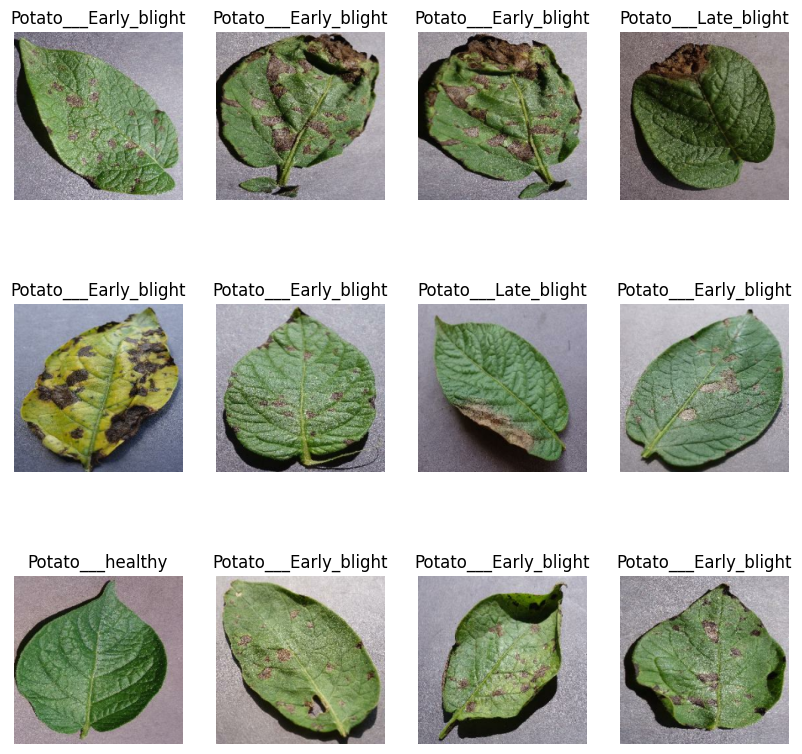

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [7]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))

Training batches: 54
Validation batches: 14


In [8]:
validation_split=0.2
subset="training"
subset="validation"

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [12]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    data_augmentation,
    resize_and_rescale,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_names), activation='softmax')
])

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []
for _, y in train_ds:
    labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7206189878711836), 1: np.float64(0.7161263507896924), 2: np.float64(4.631720430107527)}


In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7063 - loss: 0.8146 - val_accuracy: 0.8581 - val_loss: 0.3719
Epoch 2/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8677 - loss: 0.3281 - val_accuracy: 0.9488 - val_loss: 0.1975
Epoch 3/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9095 - loss: 0.2224 - val_accuracy: 0.9581 - val_loss: 0.1249
Epoch 4/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9228 - loss: 0.2061 - val_accuracy: 0.9512 - val_loss: 0.1340
Epoch 5/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9536 - loss: 0.1375 - val_accuracy: 0.9744 - val_loss: 0.0719
Epoch 6/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9640 - loss: 0.1087 - val_accuracy: 0.9535 - val_loss: 0.1167
Epoch 7/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9524 - loss: 0.1233 - val_accuracy: 0.9628 - val_loss: 0.0932
Epoch 8/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9727 - loss: 0.0850 - val_accuracy: 0.9791 - val_loss

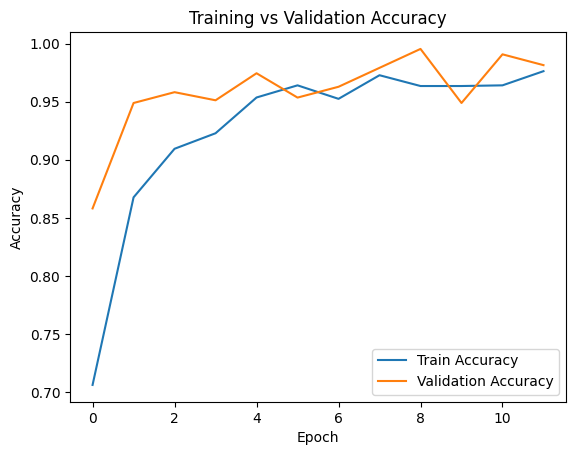

In [17]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

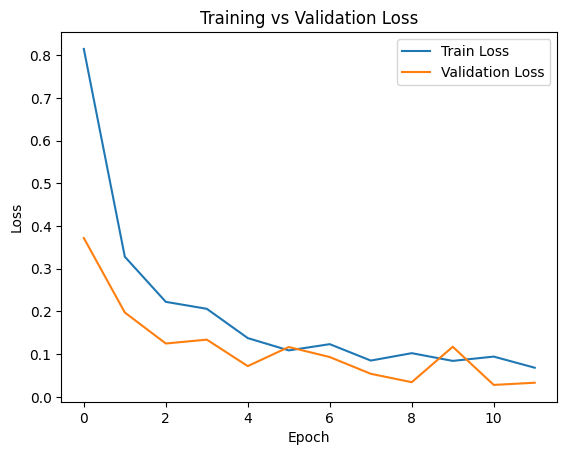

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [19]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights="imagenet"
)

In [20]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [21]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

In [22]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_tl = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
      class_weight=class_weights
)

Epoch 1/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 961ms/step - accuracy: 0.8758 - loss: 0.2929 - val_accuracy: 0.5256 - val_loss: 3.3014
Epoch 2/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 926ms/step - accuracy: 0.9658 - loss: 0.1119 - val_accuracy: 0.6070 - val_loss: 2.7785
Epoch 3/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 907ms/step - accuracy: 0.9779 - loss: 0.0559 - val_accuracy: 0.8372 - val_loss: 1.5444
Epoch 4/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 903ms/step - accuracy: 0.9861 - loss: 0.0405 - val_accuracy: 0.8651 - val_loss: 1.0094
Epoch 5/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 881ms/step - accuracy: 0.9739 - loss: 0.0829 - val_accuracy: 0.5512 - val_loss: 4.5609
Epoch 6/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 895ms/step - accuracy: 0.9785 - loss: 0.0581 - val_accuracy: 0.8326 - val_loss: 1.3637
Epoch 7/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 887ms/step - accuracy: 0.9901 - loss: 0.0283 - val_accuracy: 0.8558 - val_loss: 1.2591
Epoch 8/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 887ms/step - accuracy: 0.9890 - loss: 0.0299 - val_accu

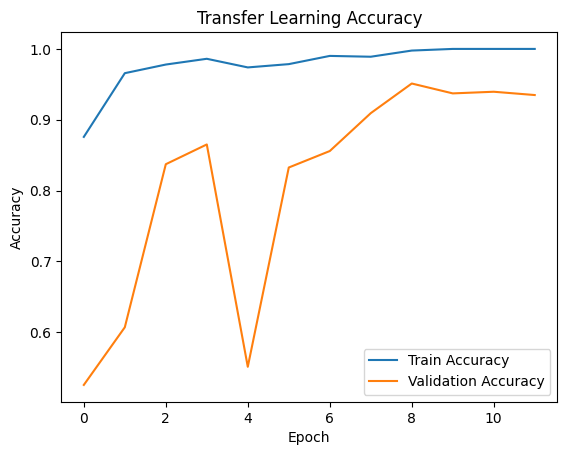

In [24]:
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()
plt.show()

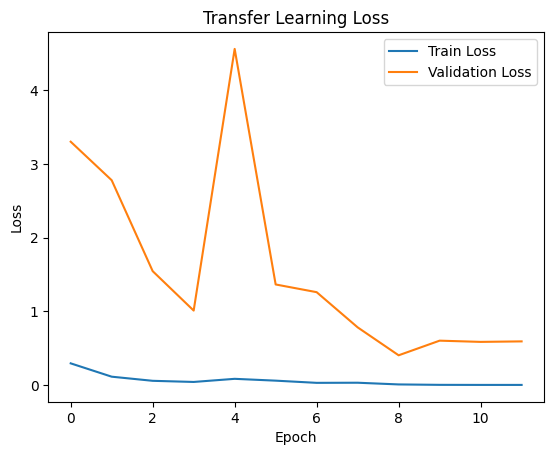

In [25]:
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

In [26]:
cnn_acc = max(history.history['val_accuracy'])
tl_acc = max(history_tl.history['val_accuracy'])

print("CNN Model Best Validation Accuracy:", cnn_acc)
print("Transfer Learning Best Validation Accuracy:", tl_acc)

CNN Model Best Validation Accuracy: 0.9953488111495972
Transfer Learning Best Validation Accuracy: 0.9511628150939941


In [27]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = transfer_model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


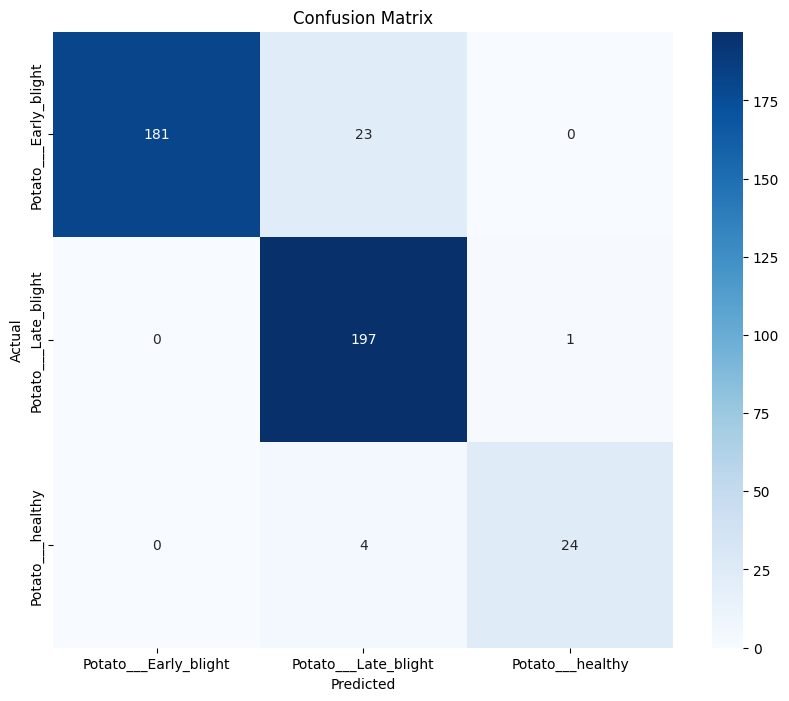

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.89      0.94       204
 Potato___Late_blight       0.88      0.99      0.93       198
     Potato___healthy       0.96      0.86      0.91        28

             accuracy                           0.93       430
            macro avg       0.95      0.91      0.93       430
         weighted avg       0.94      0.93      0.93       430



In [30]:
IMAGE_SIZE = 224

In [31]:
print(transfer_model)

<Sequential name=sequential_3, built=True>


In [32]:
img = tf.keras.preprocessing.image.load_img(
    "test_leaf.jpg",
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 127.5 - 1

prediction = transfer_model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Predicted Disease: Potato___Early_blight


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


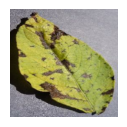

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


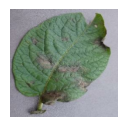

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


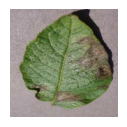

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: Potato___healthy
Actual: Potato___healthy


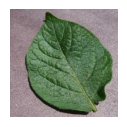

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


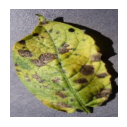

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


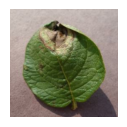

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


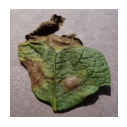

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted: Potato___Early_blight
Actual: Potato___Early_blight


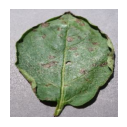

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: Potato___Late_blight
Actual: Potato___Late_blight


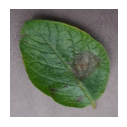

In [33]:
for images, labels in val_ds.take(1):

    for i in range(9):
        ax = plt.subplot(3, 4, i + 1)
        img = images[i]

        prediction = transfer_model.predict(np.expand_dims(img, axis=0))

        predicted_class = class_names[np.argmax(prediction)]

        actual_class = class_names[labels[i]]

        print("Predicted:", predicted_class)
        print("Actual:", actual_class)

        plt.imshow(img.numpy().astype("uint8"))
        plt.axis("off")
        plt.show()

In [34]:
print(prediction)

[[3.092795e-13 1.000000e+00 1.536129e-12]]


In [35]:
import os

# Create Models folder if it doesn't exist
os.makedirs("../Models", exist_ok=True)

# Save both models with fixed names
model.save("../Models/cnn_model.keras")
transfer_model.save("../Models/transfer_model.keras")

print("Both models saved successfully in ../Models/")

Both models saved successfully in ../Models/
